<a href="https://colab.research.google.com/github/rashigundawar24-collab/Deep-Learning/blob/main/A3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Assignment 3. Implement forward propagation and backpropagation using TensorFlow/Keras. Analyze the effect of different learning rates and the number of epochs on model performance

In [ ]:
# Import required libraries
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Load Fashion MNIST dataset
(train_data, train_labels), (test_data, test_labels) = \
    tf.keras.datasets.fashion_mnist.load_data()

print("Training Data Shape:", train_data.shape)
print("Testing Data Shape :", test_data.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training Data Shape: (60000, 28, 28)
Testing Data Shape : (10000, 28, 28)


In [3]:
# Convert images into one-dimensional arrays and normalize pixel values
train_data = train_data.reshape(train_data.shape[0], 784) / 255.0
test_data = test_data.reshape(test_data.shape[0], 784) / 255.0

print("After Preprocessing")
print("Training Data:", train_data.shape)
print("Testing Data :", test_data.shape)

After Preprocessing
Training Data: (60000, 784)
Testing Data : (10000, 784)


In [14]:
# Create a neural network model
def build_model(rate):

    network = tf.keras.Sequential([
        tf.keras.layers.Dense(96, activation='relu', input_shape=(784,)),
        tf.keras.layers.Dense(48, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

    network.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return network

In [5]:
# Compare different learning rates
learning_rate_values = [0.01, 0.001, 0.0001]

learning_results = []

for rate in learning_rate_values:

    network = build_model(rate)

    network.fit(
        train_data,
        train_labels,
        epochs=4,
        batch_size=64,
        verbose=0
    )

    test_loss, test_acc = network.evaluate(
        test_data,
        test_labels,
        verbose=0
    )

    learning_results.append([rate, test_acc])

learning_df = pd.DataFrame(
    learning_results,
    columns=["Learning Rate", "Test Accuracy"]
)

print(learning_df)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


   Learning Rate  Test Accuracy
0         0.0100         0.8545
1         0.0010         0.8717
2         0.0001         0.8488


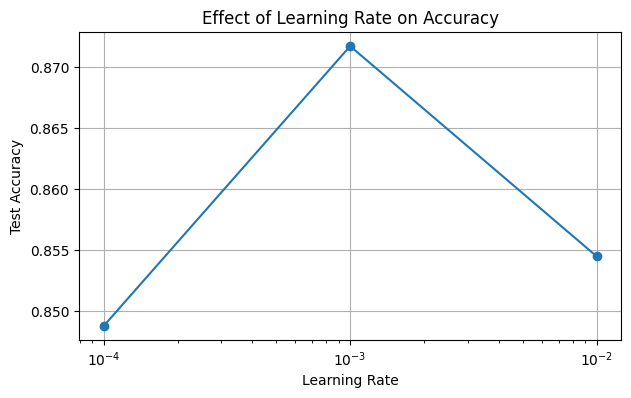

In [6]:
# Plot learning rate against accuracy
plt.figure(figsize=(7, 4))

plt.plot(
    learning_df["Learning Rate"],
    learning_df["Test Accuracy"],
    marker='o'
)

plt.xscale('log')
plt.title("Effect of Learning Rate on Accuracy")
plt.xlabel("Learning Rate")
plt.ylabel("Test Accuracy")
plt.grid(True)

plt.show()

In [7]:
# Compare different numbers of epochs
epoch_values = [4, 8, 12]

epoch_results = []

for number_of_epochs in epoch_values:

    network = build_model(0.001)

    network.fit(
        train_data,
        train_labels,
        validation_split=0.2,
        epochs=number_of_epochs,
        batch_size=64,
        verbose=0
    )

    test_loss, test_acc = network.evaluate(
        test_data,
        test_labels,
        verbose=0
    )

    epoch_results.append([number_of_epochs, test_acc])

epoch_df = pd.DataFrame(
    epoch_results,
    columns=["Number of Epochs", "Test Accuracy"]
)

print(epoch_df)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


   Number of Epochs  Test Accuracy
0                 4         0.8617
1                 8         0.8734
2                12         0.8772


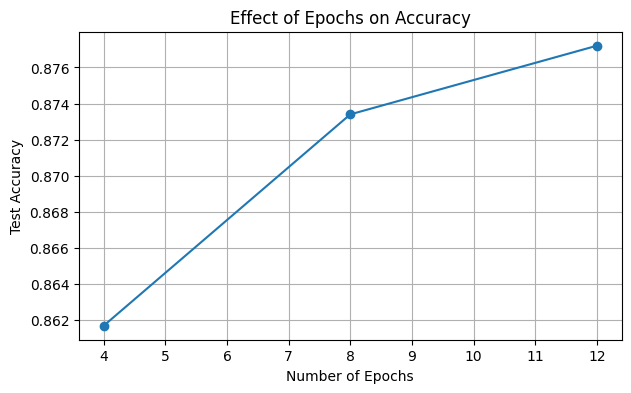

In [8]:
# Plot number of epochs against accuracy
plt.figure(figsize=(7, 4))

plt.plot(
    epoch_df["Number of Epochs"],
    epoch_df["Test Accuracy"],
    marker='o'
)

plt.title("Effect of Epochs on Accuracy")
plt.xlabel("Number of Epochs")
plt.ylabel("Test Accuracy")
plt.grid(True)

plt.show()

In [9]:
# Train the final model
final_model = build_model(0.001)

training_history = final_model.fit(
    train_data,
    train_labels,
    validation_split=0.2,
    epochs=12,
    batch_size=64
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/12
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8014 - loss: 0.5655 - val_accuracy: 0.8489 - val_loss: 0.4301
Epoch 2/12
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8575 - loss: 0.4007 - val_accuracy: 0.8552 - val_loss: 0.4028
Epoch 3/12
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8688 - loss: 0.3632 - val_accuracy: 0.8699 - val_loss: 0.3690
Epoch 4/12
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8792 - loss: 0.3317 - val_accuracy: 0.8637 - val_loss: 0.3751
Epoch 5/12
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8857 - loss: 0.3141 - val_accuracy: 0.8796 - val_loss: 0.3303
Epoch 6/12
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8880 - loss: 0.3008 - val_accuracy: 0.8718 - val_loss: 0.3592
Epoch 7/12
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8940 - loss: 0.2862 - val_accuracy: 0.8855 - val_loss: 0.3215
Epoch 8/12
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8985 - loss: 0.2764 - val_accuracy: 0.

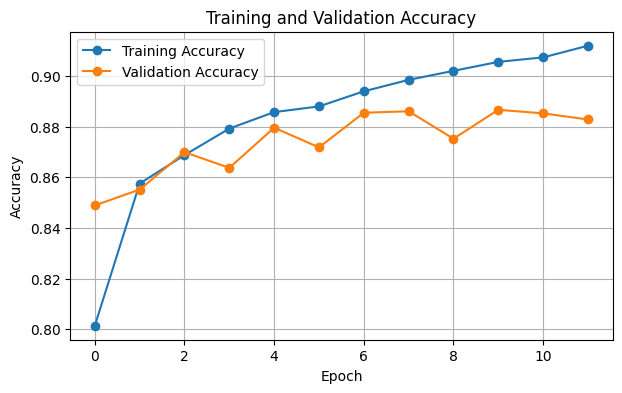

In [10]:
# Display training and validation accuracy
plt.figure(figsize=(7, 4))

plt.plot(training_history.history['accuracy'], marker='o')
plt.plot(training_history.history['val_accuracy'], marker='o')

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Training Accuracy", "Validation Accuracy"])
plt.grid(True)

plt.show()

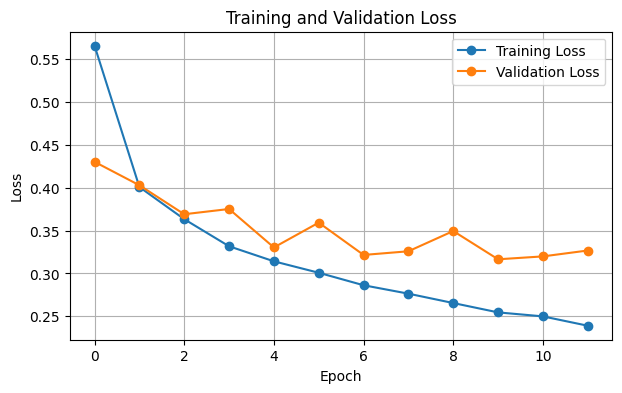

In [11]:
# Display training and validation loss
plt.figure(figsize=(7, 4))

plt.plot(training_history.history['loss'], marker='o')
plt.plot(training_history.history['val_loss'], marker='o')

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Training Loss", "Validation Loss"])
plt.grid(True)

plt.show()

In [13]:
# Evaluate the final model on test data
final_loss, final_accuracy = final_model.evaluate(
    test_data,
    test_labels
)

print("Final Test Loss:", final_loss)
print("Final Test Accuracy:", final_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8790 - loss: 0.3537
Final Test Loss: 0.3536693751811981
Final Test Accuracy: 0.8790000081062317
